|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 8:</h2>|<h1>The Capstone<h1>|
|<h2>Section:</h2>|<h1>Against the roof<h1>|
|<h2>Lecture:</h2>|<h1><b>The ratio that travels between cards<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# The ratio that travels

A throughput number belongs to one card. A floor belongs to one card too. The
two move together, so their ratio does not. This notebook builds the floor of
a decode step from four numbers, and then states it in units that do not
depend on the card.

In [2]:
# Published configs. No download: the formula needs only these numbers.
MODELS = {
    'Qwen3-0.6B':   dict(layers=28, hidden=1024, heads=16, kv_heads=8, head_dim=128,
                         intermediate=3072, vocab=151936),
    'Llama-3.2-1B': dict(layers=16, hidden=2048, heads=32, kv_heads=8, head_dim=64,
                         intermediate=8192, vocab=128256),
    'Qwen3-4B':     dict(layers=36, hidden=2560, heads=32, kv_heads=8, head_dim=128,
                         intermediate=9728, vocab=151936),
    'Llama-3.1-8B': dict(layers=32, hidden=4096, heads=32, kv_heads=8, head_dim=128,
                         intermediate=14336, vocab=128256),
}

def model_sizes(config, bytes_per_weight=2, bytes_per_kv=2):
    """-> (bytes that one decode step reads, parameters, KV bytes for each token)."""
    attention = (2 * config['hidden'] * config['heads'] * config['head_dim']       # q, o
                 + 2 * config['hidden'] * config['kv_heads'] * config['head_dim'])  # k, v
    mlp = 3 * config['hidden'] * config['intermediate']
    params = (config['layers'] * (attention + mlp)
              + config['vocab'] * config['hidden'])        # decode reads the lm_head
    kv_bytes = 2 * config['layers'] * config['kv_heads'] * config['head_dim'] * bytes_per_kv
    return params * bytes_per_weight, params, kv_bytes

for name, config in MODELS.items():
    weight_bytes, params, kv_bytes = model_sizes(config)
    print(f'{name:13} reads {weight_bytes/1e9:5.2f} GB for each step, '
          f'KV {kv_bytes/1024:4.0f} KiB for each token')

Qwen3-0.6B    reads  1.19 GB for each step, KV  112 KiB for each token
Llama-3.2-1B  reads  2.47 GB for each step, KV   32 KiB for each token
Qwen3-4B      reads  8.04 GB for each step, KV  144 KiB for each token
Llama-3.1-8B  reads 15.01 GB for each step, KV  128 KiB for each token


### The floor of one decode step

For a batch of B sequences, each with c tokens of context:

$$t_{\text{step}} \ge \max\!\Big(\frac{W}{BW},\ \frac{2PB}{\text{FLOPS}}\Big) + \frac{B \, c \, kv}{BW}$$

Divide both sides by B and multiply by BW, and the throughput ceiling comes out
in TOKENS FOR EACH GB OF READ BANDWIDTH. At a small batch the max is the
weight read, and FLOPS drops out. Then the ceiling does not depend on the card
at all.

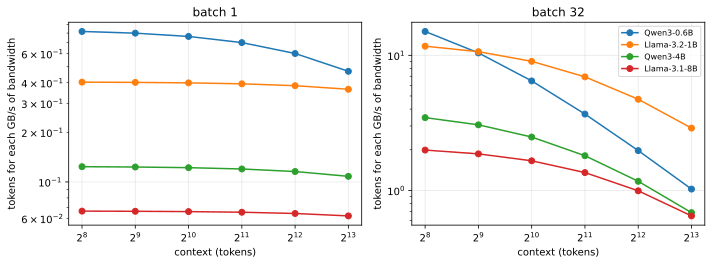

In [3]:
def tokens_per_gb(weight_bytes, kv_bytes, batch, context):
    """The ceiling of tok/s, divided by the read bandwidth in GB/s. Below the
    ridge the weight read is the larger term, so FLOPS is not in it."""
    return batch / ((weight_bytes + batch * context * kv_bytes) / 1e9)

contexts = np.array([256, 512, 1024, 2048, 4096, 8192])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=False)
for axis, batch in zip(axes, (1, 32)):
    for name, config in MODELS.items():
        weight_bytes, _, kv_bytes = model_sizes(config)
        axis.plot(contexts, [tokens_per_gb(weight_bytes, kv_bytes, batch, context)
                             for context in contexts], 'o-', label=name)
    axis.set_xscale('log', base=2)
    axis.set_yscale('log')
    axis.set(title=f'batch {batch}', xlabel='context (tokens)',
             ylabel='tokens for each GB/s of bandwidth')
    axis.grid(alpha=.3)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Two regimes, and a surprise

At batch 1 the curves are flat. The weights dominate, and the ceiling is only
1 / (weight GB). A model two times larger is two times slower.

At batch 32 the context takes over, and then the KV bytes for each token
decide. Look at Qwen3-0.6B against Llama-3.2-1B. The smaller model has 112 KiB
of KV for each token, and the larger model has 32 KiB. At long context the
larger model serves MORE tokens.

That is why a serving team picks a model by its KV bytes for each token, and
not only by its parameter count.

### And on this card

Multiply by the read bandwidth of this card, and you get this card's ceiling
in tok/s. This is the only cell with a number that belongs to one machine.

In [4]:
bandwidth_gbs = cudalib.read_bandwidth() / 1e9
print(f'read bandwidth here: {bandwidth_gbs:.0f} GB/s')
for name, config in MODELS.items():
    weight_bytes, _, kv_bytes = model_sizes(config)
    batch_one = bandwidth_gbs * tokens_per_gb(weight_bytes, kv_bytes, 1, 512)
    batch_32 = bandwidth_gbs * tokens_per_gb(weight_bytes, kv_bytes, 32, 2048)
    print(f'{name:13}  batch 1: {batch_one:6.0f} tok/s   '
          f'batch 32 at 2k context: {batch_32:6.0f} tok/s')

read bandwidth here: 326 GB/s
Qwen3-0.6B     batch 1:    261 tok/s   batch 32 at 2k context:   1199 tok/s
Llama-3.2-1B   batch 1:    131 tok/s   batch 32 at 2k context:   2260 tok/s
Qwen3-4B       batch 1:     40 tok/s   batch 32 at 2k context:    590 tok/s
Llama-3.1-8B   batch 1:     22 tok/s   batch 32 at 2k context:    442 tok/s


### The ratio that your engine must reach

These are ceilings. No engine reaches them. The capstone does not ask for a
tok/s number. It asks for a ratio: the floor of the steps that your engine
really ran, divided by the time that they took.

A card twice as fast moves both the floor and your engine. The ratio stays.
That is the number to compare between two students, two cards, or two
versions of your code.

    ./vc guide 25